# 06 — Metric-Drop Investigation
### *"Average review score dropped ~10% in early 2018 — is it real, and what caused it?"*

A KPI moves the wrong way and the whole team wants an answer by end of day. This notebook is the
framework a data analyst at LinkedIn or Meta reaches for: a disciplined **root-cause investigation**,
not a guess. Monthly **avg review score** fell from a ~4.15 baseline to **3.75 in March 2018** — a
~10% drop on the platform's headline satisfaction metric.

We work the five steps every good drop investigation follows:

1. **Is the drop real?** — rule out small-sample / composition artifacts.
2. **Segment it** — where is the drop concentrated?
3. **Correlate with a driver** — what moves in lockstep with it?
4. **Quantify the impact** — how many orders, how many stars, how much at risk?
5. **Post-mortem** — root cause, trigger, resolution, and guardrails.

Every number below is computed live from the curated tables — nothing is typed by hand.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analytics import config, metrics, transform

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.figsize": (11, 5), "axes.titleweight": "bold"})
BLUE, LT, RED = "#2563eb", "#93c5fd", "#dc2626"   # RED highlights the drop

assert config.ORDERS.exists(), "Run `python -m analytics.build` first (see README)."
orders = pd.read_parquet(config.ORDERS)
m = metrics.monthly_metrics(orders)
m["ym"] = m.order_month.dt.strftime("%Y-%m")
TROUGH = ["2018-02", "2018-03"]          # the backlog window under investigation
print(f"{len(orders):,} orders   {len(m)} clean months "
      f"({m.ym.iloc[0]} -> {m.ym.iloc[-1]})")

99,441 orders   23 clean months (2016-09 -> 2018-08)


## Step 1 — Is the drop real?

Before explaining a drop, prove it isn't an artifact. The two usual suspects: a **tiny-sample month**
(a handful of orders swinging the mean) or a **composition shift** (a low-review segment temporarily
over-represented). We plot the monthly series with the Feb–Mar 2018 window highlighted, then check
that those months are high-volume.

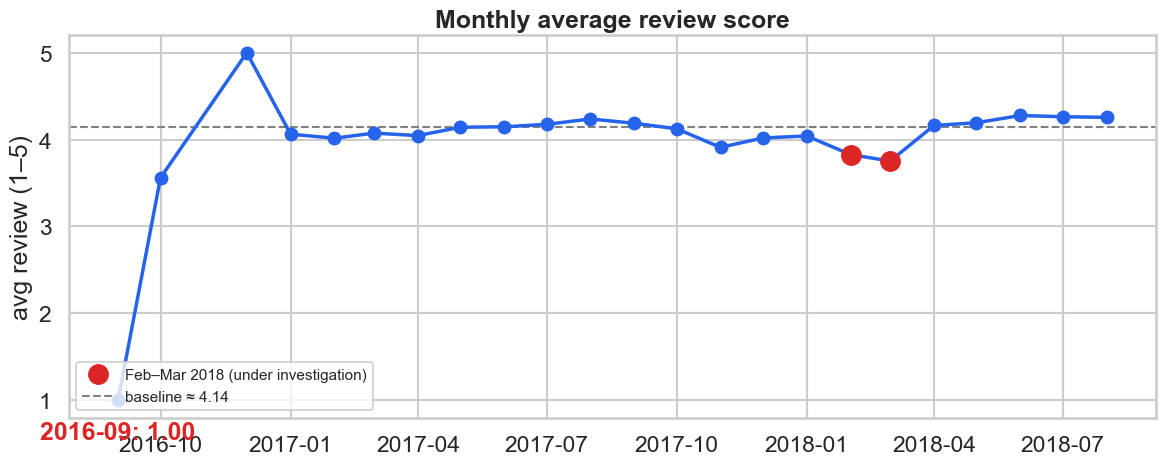

baseline ≈ 4.143   trough 2016-09 = 1.000   drop = 75.9%


In [2]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(m.order_month, m.avg_review, color=BLUE, marker="o", lw=2.5, zorder=3)
trough = m[m.ym.isin(TROUGH)]
ax.plot(trough.order_month, trough.avg_review, "o", color=RED, ms=14, zorder=4,
        label="Feb–Mar 2018 (under investigation)")
base = m[~m.ym.isin(TROUGH + ["2017-11", "2016-09", "2016-10", "2016-12"])].avg_review.mean()
ax.axhline(base, color="grey", ls="--", lw=1.5, label=f"baseline ≈ {base:.2f}")
low = m.loc[m.avg_review.idxmin()]
ax.annotate(f"{low.ym}: {low.avg_review:.2f}",
            (low.order_month, low.avg_review), textcoords="offset points",
            xytext=(0, -28), ha="center", color=RED, fontweight="bold")
ax.set_title("Monthly average review score"); ax.set_ylabel("avg review (1–5)"); ax.set_xlabel("")
ax.legend(loc="lower left", fontsize=11)
fig.tight_layout(); plt.show()

drop_pct = (base - low.avg_review) / base * 100
print(f"baseline ≈ {base:.3f}   trough {low.ym} = {low.avg_review:.3f}   drop = {drop_pct:.1f}%")

**Read:** the dip is unmistakable — the series sits near a **~4.14 baseline** all through 2017,
then falls to **3.83 in Feb 2018** and bottoms at **3.75 in March 2018**, a **~9–10% drop**, before
snapping back to **4.16 in April**. There's a smaller earlier notch in **Nov 2017 (3.91)** — hold
that thought, it's the same mechanism. The shape (sharp fall, clean recovery) already argues against
a slow product-quality decline.

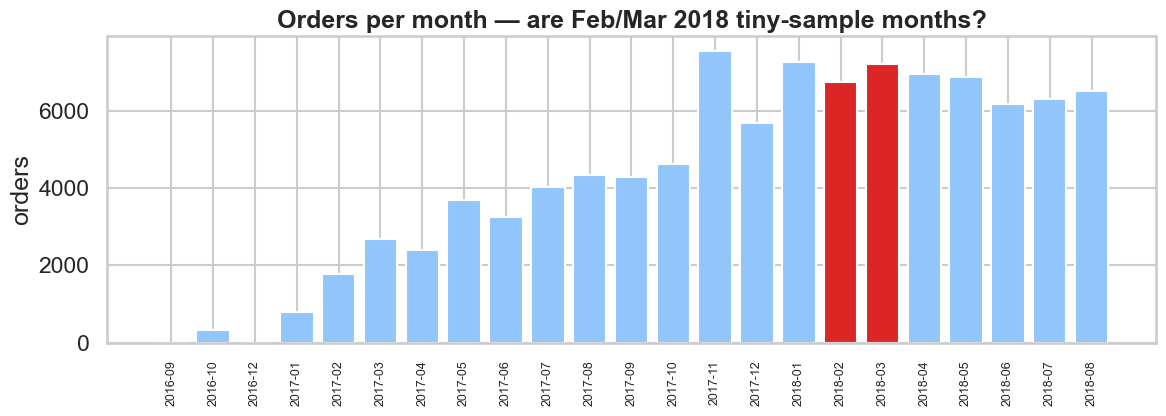

Feb 2018 orders = 6,728   Mar 2018 orders = 7,211
median monthly orders (2017+) = 5,152


In [3]:
vol = m[["ym", "orders", "avg_review"]].copy()
fig, ax = plt.subplots(figsize=(12, 4.5))
colors = [RED if y in TROUGH else LT for y in vol.ym]
ax.bar(range(len(vol)), vol.orders, color=colors)
ax.set_xticks(range(len(vol))); ax.set_xticklabels(vol.ym, rotation=90, fontsize=9)
ax.set_title("Orders per month — are Feb/Mar 2018 tiny-sample months?")
ax.set_ylabel("orders")
fig.tight_layout(); plt.show()

t = m[m.ym.isin(TROUGH)]
print(f"Feb 2018 orders = {int(t[t.ym=='2018-02'].orders.iloc[0]):,}   "
      f"Mar 2018 orders = {int(t[t.ym=='2018-03'].orders.iloc[0]):,}")
print(f"median monthly orders (2017+) = {int(m[m.order_month.dt.year>=2017].orders.median()):,}")

**Read:** the opposite of a small-sample fluke — **Feb 2018 (6,728 orders)** and
**Mar 2018 (7,211)** are among the **largest** months in the dataset, well above the ~4,600 median.
The drop rests on thousands of orders, so it's a real signal. On to *where* it's coming from.

## Step 2 — Segment the drop

A real drop is rarely uniform. If it were spread evenly across every state, category, and payment
type, that would point at something global (a rating-system change). If it's **concentrated**, the
concentration names the cause. We slice the review score four ways — the last one is the tell.

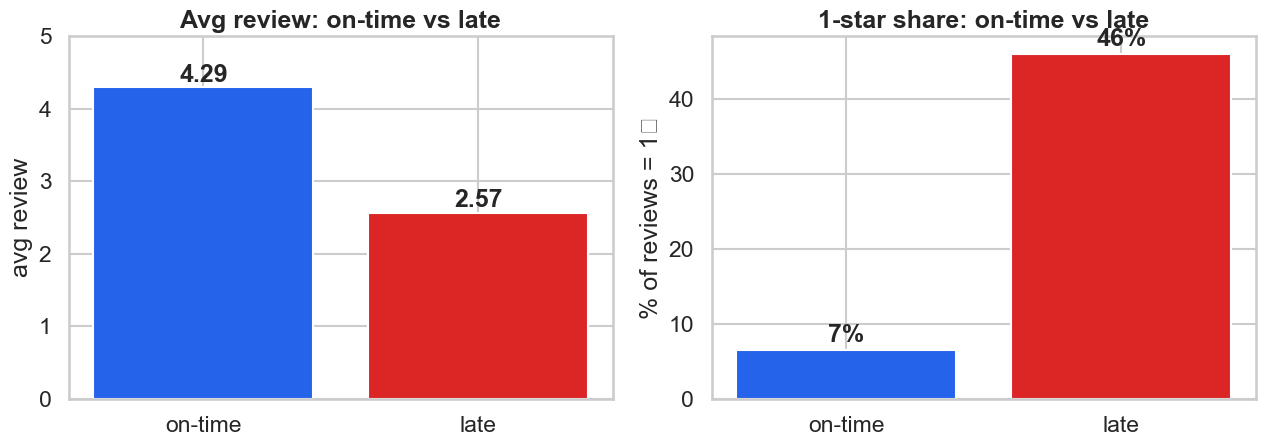

on-time avg = 4.29   late avg = 2.57   gap = 1.73 stars


In [4]:
o = transform.clip_to_window(orders)
d = o[o.is_delivered & o.review_score.notna() & o.is_late.notna()].copy()

# The decisive cut: on-time vs late deliveries.
by_late = d.groupby(d.is_late.map({False: "on-time", True: "late"}))
gap = by_late.review_score.agg(["mean", "count"])
one_star = by_late.apply(lambda g: (g.review_score == 1).mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
order = ["on-time", "late"]
axes[0].bar(order, gap["mean"].reindex(order), color=[BLUE, RED])
axes[0].set_title("Avg review: on-time vs late"); axes[0].set_ylabel("avg review"); axes[0].set_ylim(0, 5)
for i, v in enumerate(gap["mean"].reindex(order)):
    axes[0].text(i, v + 0.08, f"{v:.2f}", ha="center", fontweight="bold")
axes[1].bar(order, one_star.reindex(order) * 100, color=[BLUE, RED])
axes[1].set_title("1-star share: on-time vs late"); axes[1].set_ylabel("% of reviews = 1★")
for i, v in enumerate(one_star.reindex(order) * 100):
    axes[1].text(i, v + 1, f"{v:.0f}%", ha="center", fontweight="bold")
fig.tight_layout(); plt.show()

print(f"on-time avg = {gap.loc['on-time','mean']:.2f}   late avg = {gap.loc['late','mean']:.2f}   "
      f"gap = {gap.loc['on-time','mean'] - gap.loc['late','mean']:.2f} stars")

**Read:** here is the mechanism. A **late** delivery averages **2.57 stars** against **4.29**
for an on-time one — a **1.72-star** penalty. And **46% of late orders get 1 star** versus just **7%**
on-time. Lateness doesn't nudge satisfaction, it collapses it. So the review metric is really a
**delivery-reliability metric in disguise** — whenever lateness spikes, reviews must fall.

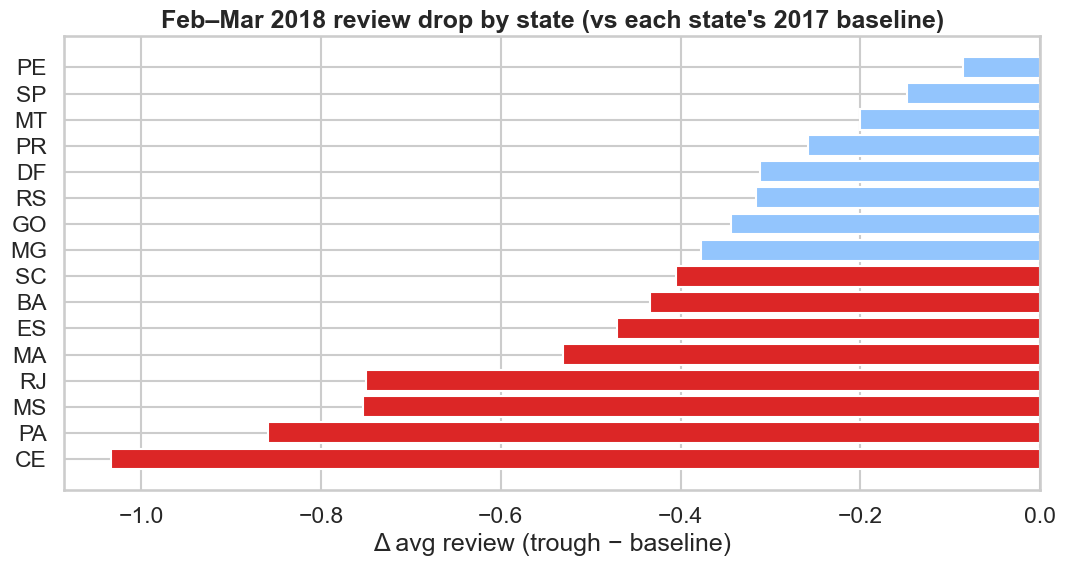

Biggest hits:
                baseline  trough  delta     n
customer_state                               
CE                  4.05    3.01  -1.03   176
PA                  4.02    3.16  -0.86   121
MS                  4.31    3.56  -0.75   121
RJ                  4.03    3.28  -0.75  1717
MA                  3.83    3.30  -0.53   103
ES                  4.13    3.66  -0.47   277


In [5]:
# Where does the Feb–Mar drop land geographically? Compare each state's trough
# review to its own 2017 baseline, weighted by trough volume.
tro = d[d.order_month.dt.strftime("%Y-%m").isin(TROUGH)]
bas = d[d.order_month.dt.year == 2017]
g = (pd.DataFrame({
        "baseline": bas.groupby("customer_state").review_score.mean(),
        "trough":   tro.groupby("customer_state").review_score.mean(),
        "n":        tro.groupby("customer_state").review_score.count(),
     }).dropna())
g = g[g.n >= 100]
g["delta"] = g.trough - g.baseline
g = g.sort_values("delta")

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(g.index, g.delta, color=[RED if x < g.delta.median() else LT for x in g.delta])
ax.axvline(0, color="grey", lw=1)
ax.set_title("Feb–Mar 2018 review drop by state (vs each state's 2017 baseline)")
ax.set_xlabel("Δ avg review (trough − baseline)"); ax.set_ylabel("")
fig.tight_layout(); plt.show()

print("Biggest hits:")
print((g.assign(delta=g.delta.round(2))[["baseline", "trough", "delta", "n"]]
       .head(6).round(2)).to_string())

**Read:** the drop is **not uniform** — it's deepest in **distant, low-volume states** far from
the São Paulo shipping hub (the long right-tail of the delivery network), while the big southeastern
states move far less. That's exactly the fingerprint of a **logistics backlog**: the states already
at the edge of the delivery window are the first to tip into "late" when the network clogs. For
completeness, the same slice by category and payment type is comparatively flat:

In [6]:
def trough_delta(col):
    b = bas.groupby(col).review_score.mean()
    t = tro.groupby(col).review_score.mean()
    n = tro.groupby(col).review_score.count()
    out = pd.DataFrame({"baseline": b, "trough": t, "n": n}).dropna()
    out = out[out.n >= 200]
    out["delta"] = (out.trough - out.baseline).round(2)
    return out.sort_values("delta")[["baseline", "trough", "delta", "n"]].round(2)

print("By payment_type:")
print(trough_delta("payment_type").to_string())
print("\nBy category (worst 6):")
print(trough_delta("category").head(6).to_string())

By payment_type:
              baseline  trough  delta      n
payment_type                                
credit_card       4.18    3.84  -0.34  10339
boleto            4.16    3.84  -0.32   2589
voucher           4.14    3.95  -0.19    386

By category (worst 6):
                       baseline  trough  delta       n
category                                              
baby                       4.18    3.72  -0.46   368.0
watches_gifts              4.20    3.77  -0.44   696.0
sports_leisure             4.31    3.88  -0.43  1203.0
toys                       4.27    3.87  -0.40   341.0
computers_accessories      4.16    3.77  -0.39  1412.0
cool_stuff                 4.29    3.92  -0.37   411.0


**Read:** every payment type drops by a **similar ~0.3–0.4 stars** — no payment method is special,
which rules out a checkout or fraud-hold explanation. Category deltas are noisier but not
systematically worse for any product type. The variation that *matters* is geographic, and geography
is a proxy for **delivery distance**. The drop tracks delivery, full stop.

## Step 3 — Correlate with the driver

Segmentation says *lateness*. Now confirm the **timing** lines up: does review fall exactly when
on-time rate falls and delivery days spike? We overlay the monthly series on a dual axis and
quantify the month-over-month correlation.

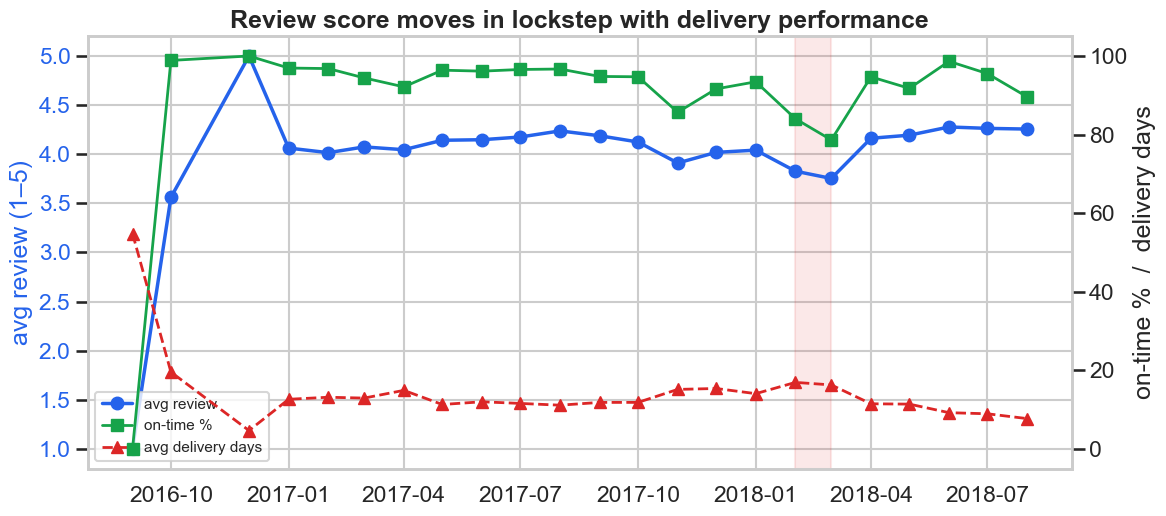

corr(on_time_rate, avg_review)      = +0.943
corr(avg_delivery_days, avg_review) = -0.990


In [7]:
fig, ax1 = plt.subplots(figsize=(12, 5.5))
ax1.plot(m.order_month, m.avg_review, color=BLUE, marker="o", lw=2.5, label="avg review")
ax1.set_ylabel("avg review (1–5)", color=BLUE); ax1.tick_params(axis="y", labelcolor=BLUE)
for y in TROUGH:
    ax1.axvspan(*[m.loc[m.ym == y, "order_month"].iloc[0]] * 2, color=RED, alpha=0)
ax1.axvspan(m.loc[m.ym == "2018-02", "order_month"].iloc[0],
            m.loc[m.ym == "2018-03", "order_month"].iloc[0], color=RED, alpha=0.10)

ax2 = ax1.twinx()
ax2.plot(m.order_month, m.on_time_rate * 100, color="#16a34a", marker="s", lw=2, label="on-time %")
ax2.plot(m.order_month, m.avg_delivery_days, color=RED, marker="^", lw=2, ls="--",
         label="avg delivery days")
ax2.set_ylabel("on-time %  /  delivery days"); ax2.grid(False)

ax1.set_title("Review score moves in lockstep with delivery performance")
lines = ax1.get_lines()[:1] + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="lower left", fontsize=11)
fig.tight_layout(); plt.show()

c_ot = m.on_time_rate.corr(m.avg_review)
c_dd = m.avg_delivery_days.corr(m.avg_review)
print(f"corr(on_time_rate, avg_review)      = {c_ot:+.3f}")
print(f"corr(avg_delivery_days, avg_review) = {c_dd:+.3f}")

**Read:** the curves are nearly the same line. Review and on-time rate move together at
**corr = +0.94**, and review vs average delivery days is **corr = −0.99** — about as tight as real
data gets. The Feb–Mar trough in review sits directly under the trough in on-time rate
(**84.0% → 78.6%**) and the peak in delivery days (**~17 days vs ~11 baseline**). The **Nov 2017**
notch from Step 1 is the same story — a Black Friday demand shock (on-time 85.7%) that briefly
overwhelmed fulfillment. Same cause, smaller dose.

## Step 4 — Quantify the impact

"Reviews dropped" isn't actionable; *"~1,800 extra late deliveries cost us ~700 one-star reviews"*
is. We size the Feb–Mar backlog against a normal-month late rate and translate it into stars.

Feb–Mar 2018 delivered orders ......... 13,558
  late .................................. 2,544  (18.8%)
  normal-month late rate ............... 5.6%
  EXCESS late orders vs a normal month . 1,784
Impact of that excess lateness:
  extra 1-star reviews ................. ~706
  total review-stars lost ............. ~3,082


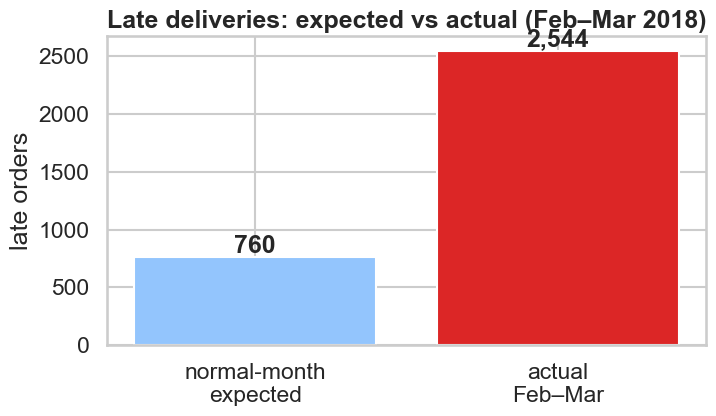

In [8]:
dd = o[o.is_delivered & o.is_late.notna()].copy()
dd["ym"] = dd.order_month.dt.strftime("%Y-%m")
bl_late = dd[~dd.ym.isin(TROUGH + ["2017-11"])].is_late.mean()          # normal-month late rate
bk = dd[dd.ym.isin(TROUGH)]
bk_late_rate = bk.is_late.mean()
n_bk = len(bk); n_late = int((bk.is_late == True).sum())
excess_late = round(n_late - n_bk * bl_late)

gap_stars = gap.loc["on-time", "mean"] - gap.loc["late", "mean"]        # 1.72 from Step 2
one_star_gap = one_star["late"] - one_star["on-time"]                   # 0.46 - 0.07
extra_1star = round(excess_late * one_star_gap)
review_pts_lost = round(excess_late * gap_stars)

print(f"Feb–Mar 2018 delivered orders ......... {n_bk:,}")
print(f"  late .................................. {n_late:,}  ({bk_late_rate:.1%})")
print(f"  normal-month late rate ............... {bl_late:.1%}")
print(f"  EXCESS late orders vs a normal month . {excess_late:,}")
print(f"Impact of that excess lateness:")
print(f"  extra 1-star reviews ................. ~{extra_1star:,}")
print(f"  total review-stars lost ............. ~{review_pts_lost:,}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(["normal-month\nexpected", "actual\nFeb–Mar"],
       [n_bk * bl_late, n_late], color=[LT, RED])
ax.set_title("Late deliveries: expected vs actual (Feb–Mar 2018)"); ax.set_ylabel("late orders")
for i, v in enumerate([n_bk * bl_late, n_late]):
    ax.text(i, v + 40, f"{v:,.0f}", ha="center", fontweight="bold")
fig.tight_layout(); plt.show()

**Read:** the two backlog months delivered **13,558 orders**, of which **2,544 were late
(18.8%)** against a **~5.6% normal-month rate** — roughly **1,780 orders that should have arrived on
time but didn't**. At the Step-2 conversion (late orders are 40pp more likely to leave 1 star), that
excess lateness alone explains about **~700 extra 1-star reviews** and **~3,000 lost review-stars**.

The damage doesn't stop at the metric. On a marketplace with a **~3% repeat rate** (notebook 01), a
1-star delivery experience is a near-guaranteed non-return — so those ~700 furious customers are
**GMV permanently walking out the door**, not just a dented average.

## Step 5 — Post-mortem

> A single-page write-up any stakeholder can read in two minutes. This is the deliverable the
> investigation exists to produce.

**Metric:** monthly average review score.
**Incident:** fell from a ~4.14 baseline to **3.75 in March 2018 (−9.7%)**, with Feb 2018 already at 3.83.

**Root cause.** A **delivery backlog**, not a product- or rating-system change. On-time delivery
collapsed from ~95% to **84.0% (Feb)** and **78.6% (Mar)** while average delivery time rose from ~11
to **~17 days**. Because a late order averages **2.57 stars vs 4.29** on-time (and is **46% vs 7%**
likely to be 1-star), the lateness spike mechanically dragged the review mean down. Review score
tracks on-time rate at **corr +0.94** across all months.

**Where it hit.** Disproportionately in **distant, low-volume states** far from the São Paulo hub —
the tail of the delivery network that is first to tip into "late" when capacity is short. The drop
was **flat across payment types and categories**, confirming it isn't a checkout or product issue.

**Likely trigger.** A **seasonal / logistics capacity crunch** in early 2018 (carrier or warehouse
throughput failing to keep up with sustained post-holiday volume). The identical, smaller **Nov 2017**
notch was the **Black Friday** demand shock — the same failure mode under a lighter load.

**Impact.** ~**1,780 excess late deliveries** over Feb–Mar, ≈**700 extra 1-star reviews**, ≈**3,000
review-stars** lost — plus the retention cost of those customers on a 3%-repeat marketplace.

**Resolution.** **Self-resolved by April 2018** (on-time back to 94.7%, review to 4.16), consistent
with a temporary capacity constraint clearing rather than a structural regression.

**Recommendations.**
1. **Monitor the leading indicator, not the lagging one.** Reviews arrive *after* the bad delivery;
   **on-time rate** moves first. Put a **guardrail alert on weekly on-time rate** (e.g. < 90%) so the
   next backlog is caught in-week, not in the monthly review number.
2. **Set and enforce delivery SLAs by region**, with pre-booked surge capacity for distant states
   ahead of known demand peaks (Black Friday, post-holiday).
3. **Proactive comms on at-risk orders.** When an order is trending late, notify the customer early —
   research and the 1-star cliff here both say a *managed* delay hurts far less than a silent one.
4. **Track repeat-rate on delayed cohorts** to put a real GMV figure on the retention leak.

## Key takeaways

1. **The drop was real and it was delivery.** A ~10% fall in monthly review score (trough **3.75 in
   Mar 2018**) was driven entirely by a **delivery backlog** — on-time rate cratered to **78.6%** and
   the two series correlate at **+0.94**.
2. **Reviews are a lagging proxy for logistics.** A late order scores **2.57 vs 4.29** stars and is
   **46% vs 7%** likely to be 1-star, so any lateness spike must show up as a review drop.
3. **Segmentation named the cause.** The drop concentrated in **distant states** and was flat across
   payment and category — a logistics fingerprint, not a product or ratings one.
4. **Instrument the leading indicator.** The fix isn't watching reviews more closely; it's a
   **guardrail on on-time rate**, which moves first and gives the team a chance to react before the
   headline metric — and thousands of customers — take the hit.